Conda env : Base 

# start

In [ ]:
import pandas as pd

csv_path = "/home/khw/IBVS-interbotix/src/logs/ibvs_sim_173740.csv"

In [3]:
df = pd.read_csv(csv_path)
df.columns

Index(['iteration', 'error_magnitude', 'distance_to_target',
       'oracle_orientation_diff', 'num_matched_keypoints', 'robot_pos_x',
       'robot_pos_y', 'robot_pos_z', 'robot_orn_x', 'robot_orn_y',
       'robot_orn_z', 'target_pos_x', 'target_pos_y', 'target_pos_z',
       'image_path'],
      dtype='object')

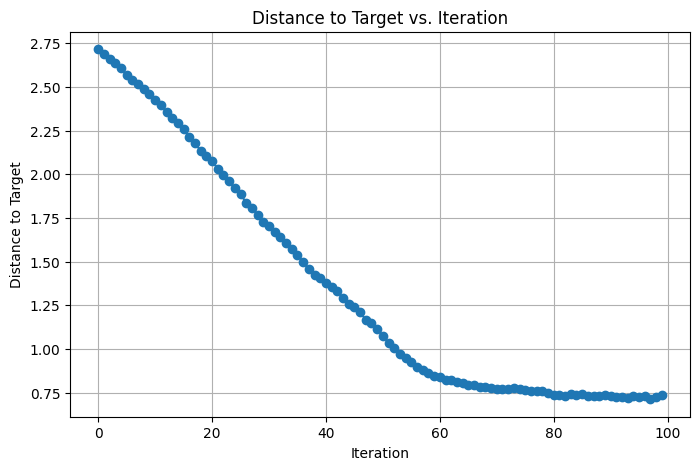

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(df['iteration'], df['distance_to_target'], marker='o')
plt.xlabel('Iteration')
plt.ylabel('Distance to Target')
plt.title('Distance to Target vs. Iteration')
plt.grid(True)

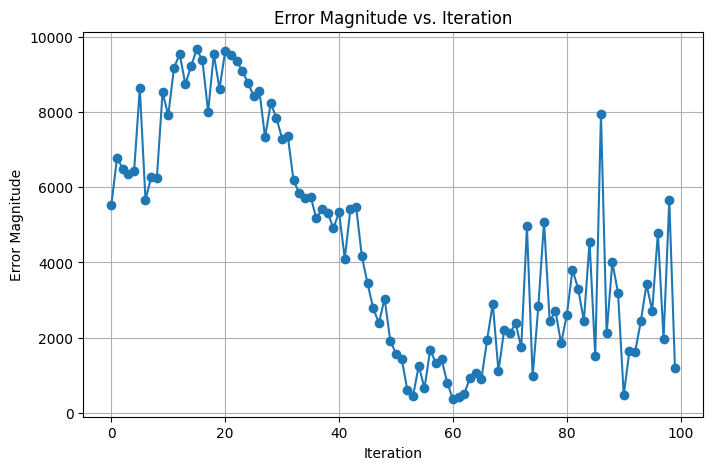

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(df['iteration'], df['error_magnitude'], marker='o')
plt.xlabel('Iteration')
plt.ylabel('Error Magnitude')
plt.title('Error Magnitude vs. Iteration')
plt.grid(True)

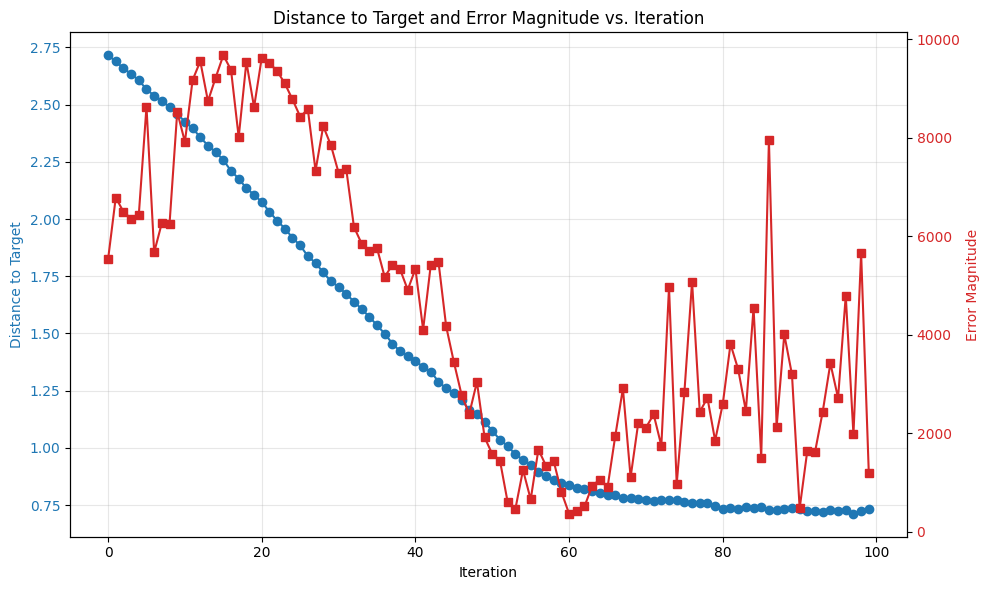

In [9]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10,6))

# Plot distance to target on the left y-axis
color = 'tab:blue'
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Distance to Target', color=color)
ax1.plot(df['iteration'], df['distance_to_target'], marker='o', label='Distance to Target', color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# Create a second y-axis that shares the same x-axis
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Error Magnitude', color=color)
ax2.plot(df['iteration'], df['error_magnitude'], marker='s', label='Error Magnitude', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Distance to Target and Error Magnitude vs. Iteration')
fig.tight_layout()
plt.show()

This happens because of the mismatch between target image size and set goal distance.

However, this is NOT a problem is real experiments, because in a single demonstration the camera can record the EEF stopping at precisely the desired location.

**Update :** This will look very ugly. We need a stopping condition, even for sim.

### Orientation vs iteration

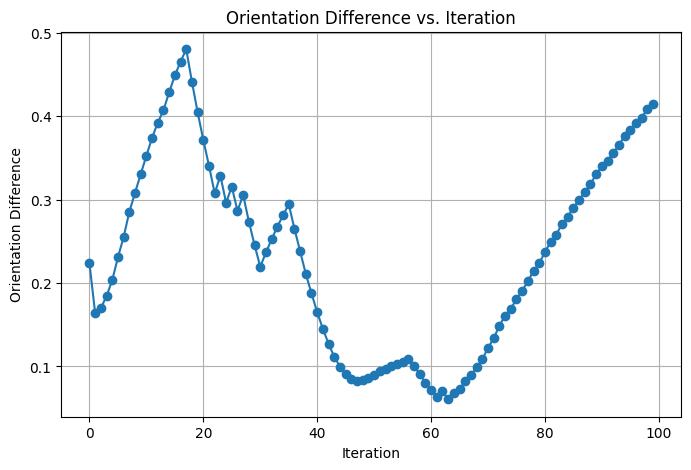

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(df['iteration'], df['oracle_orientation_diff'], marker='o')
plt.xlabel('Iteration')
plt.ylabel('Orientation Difference')
plt.title('Orientation Difference vs. Iteration')
plt.grid(True)

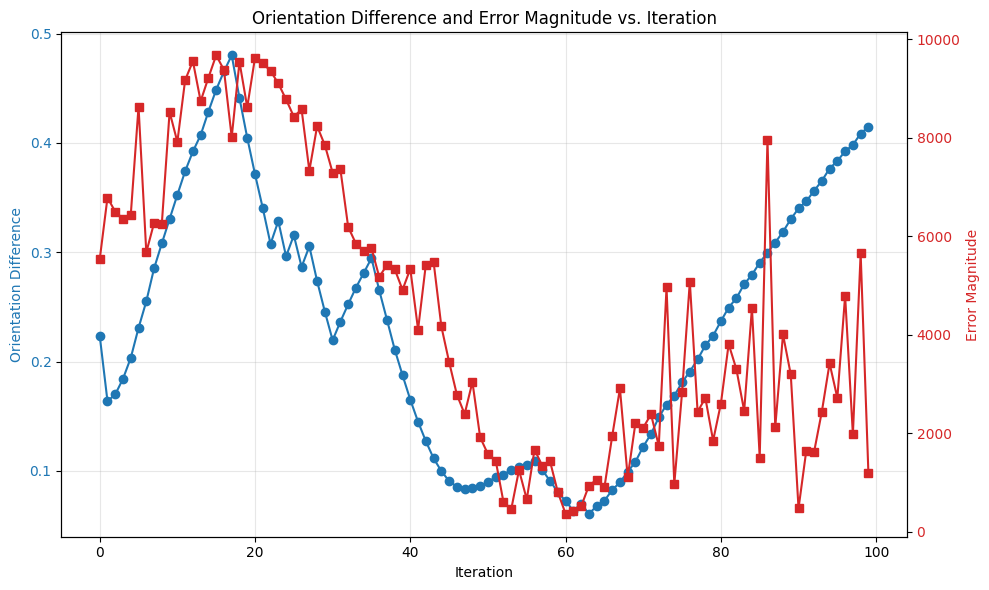

In [11]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10,6))

# Plot orientation difference on the left y-axis
color = 'tab:blue'
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Orientation Difference', color=color)
ax1.plot(df['iteration'], df['oracle_orientation_diff'], marker='o', label='Orientation Difference', color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# Create a second y-axis that shares the same x-axis
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Error Magnitude', color=color)
ax2.plot(df['iteration'], df['error_magnitude'], marker='s', label='Error Magnitude', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Orientation Difference and Error Magnitude vs. Iteration')
fig.tight_layout()
plt.show()

# Visualize Giraffe Straight line

In [ ]:
import pandas as pd
csv_path = "/home/khw/IBVS-interbotix/src/logs/straight_line_003.csv"
df = pd.read_csv(csv_path)
df.columns

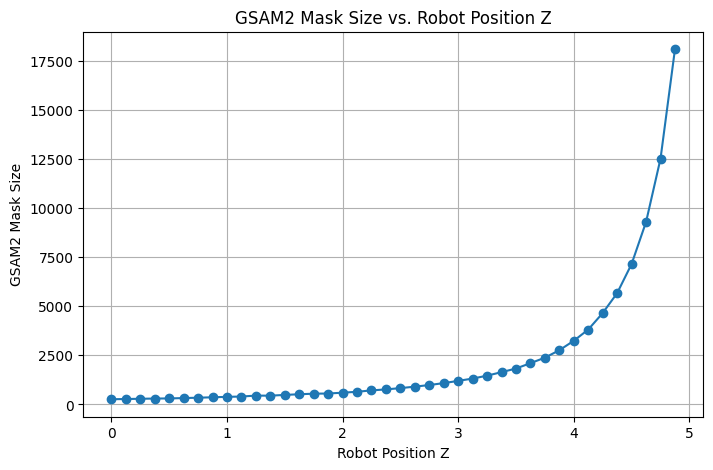

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(df['robot_pos_y'], df['gsam2_mask_size'], marker='o')
plt.xlabel('Robot Position Z')
plt.ylabel('GSAM2 Mask Size')
plt.title('GSAM2 Mask Size vs. Robot Position Z')
plt.grid(True)

# LightGlue Straight line

In [17]:
import pandas as pd
csv_path = "/home/khw/IBVS-interbotix/results/lightglue_straight_line.csv"
df = pd.read_csv(csv_path)
df.columns

Index(['iteration', 'robot_pos_x', 'robot_pos_y', 'robot_pos_z', 'robot_orn_x',
       'robot_orn_y', 'robot_orn_z', 'distance_traveled', 'lightglue_enabled',
       'num_matches', 'image_path'],
      dtype='object')

Text(0.5, 1.0, 'Number of LightGlue Matches vs. Robot Position Y')

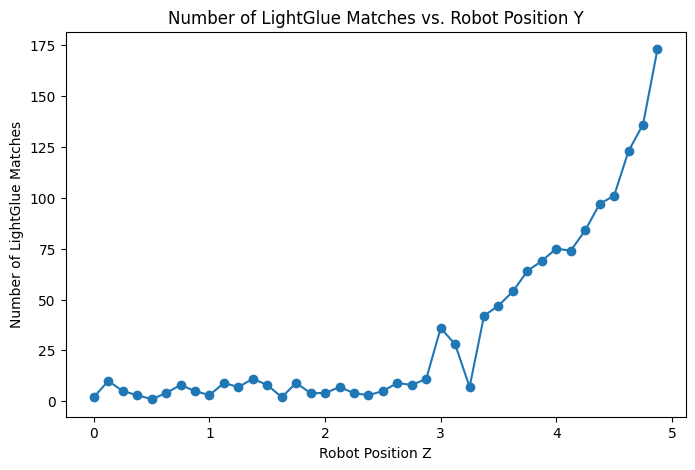

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(df['robot_pos_y'], df['num_matches'], marker='o')
plt.xlabel('Robot Position Z')
plt.ylabel('Number of LightGlue Matches')
plt.title('Number of LightGlue Matches vs. Robot Position Y')
# plt.grid(True)

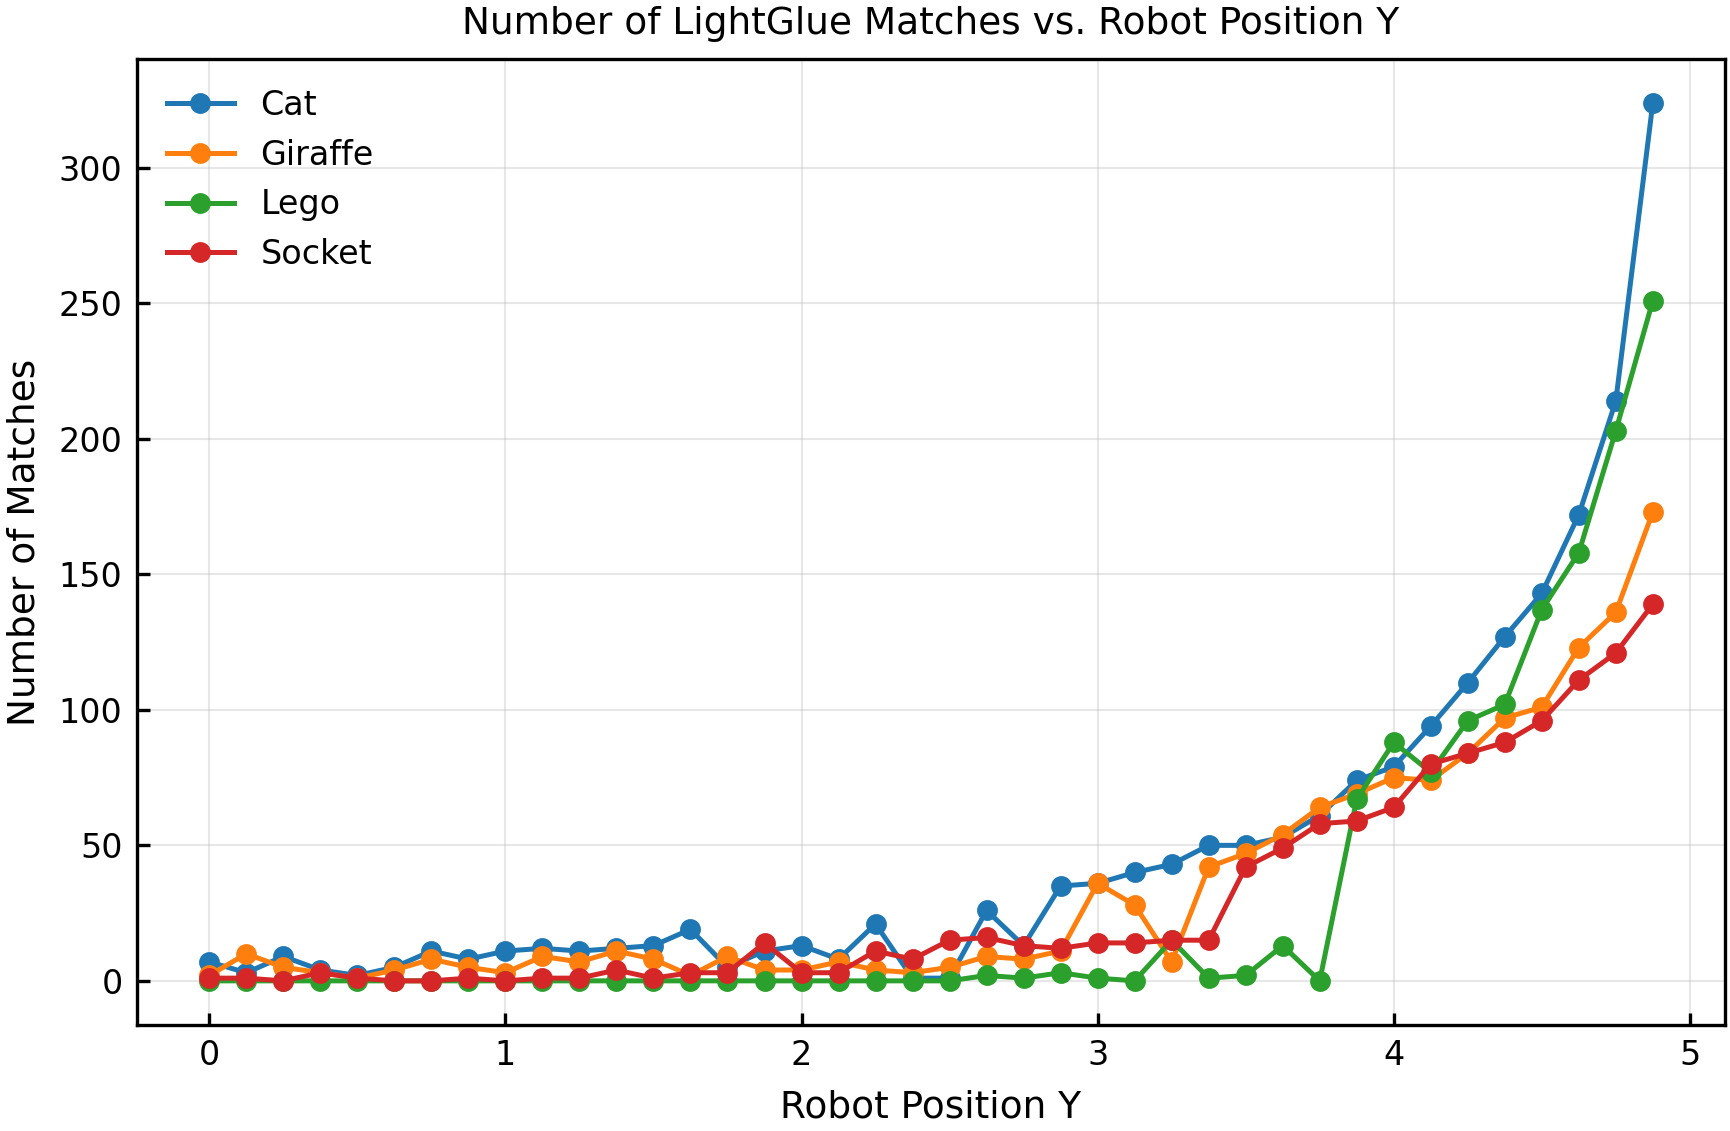

In [27]:
# Plot all 4 CSV files: pos_y vs num_matches
import pandas as pd
import matplotlib.pyplot as plt

# Read all 4 CSV files
csv_files = {
    'Cat': '/home/khw/IBVS-interbotix/results/lightglue_straight_line_cat.csv',
    'Giraffe': '/home/khw/IBVS-interbotix/results/lightglue_straight_line_giraffe.csv',
    'Lego': '/home/khw/IBVS-interbotix/results/lightglue_straight_line_lego.csv',
    'Socket': '/home/khw/IBVS-interbotix/results/lightglue_straight_line_socket.csv'
}

plt.figure(figsize=(6, 4))

# Plot each dataset
for name, path in csv_files.items():
    df = pd.read_csv(path)
    plt.plot(df['robot_pos_y'], df['num_matches'], marker='o', label=name)

plt.xlabel('Robot Position Y')
plt.ylabel('Number of Matches')
plt.title('Number of LightGlue Matches vs. Robot Position Y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

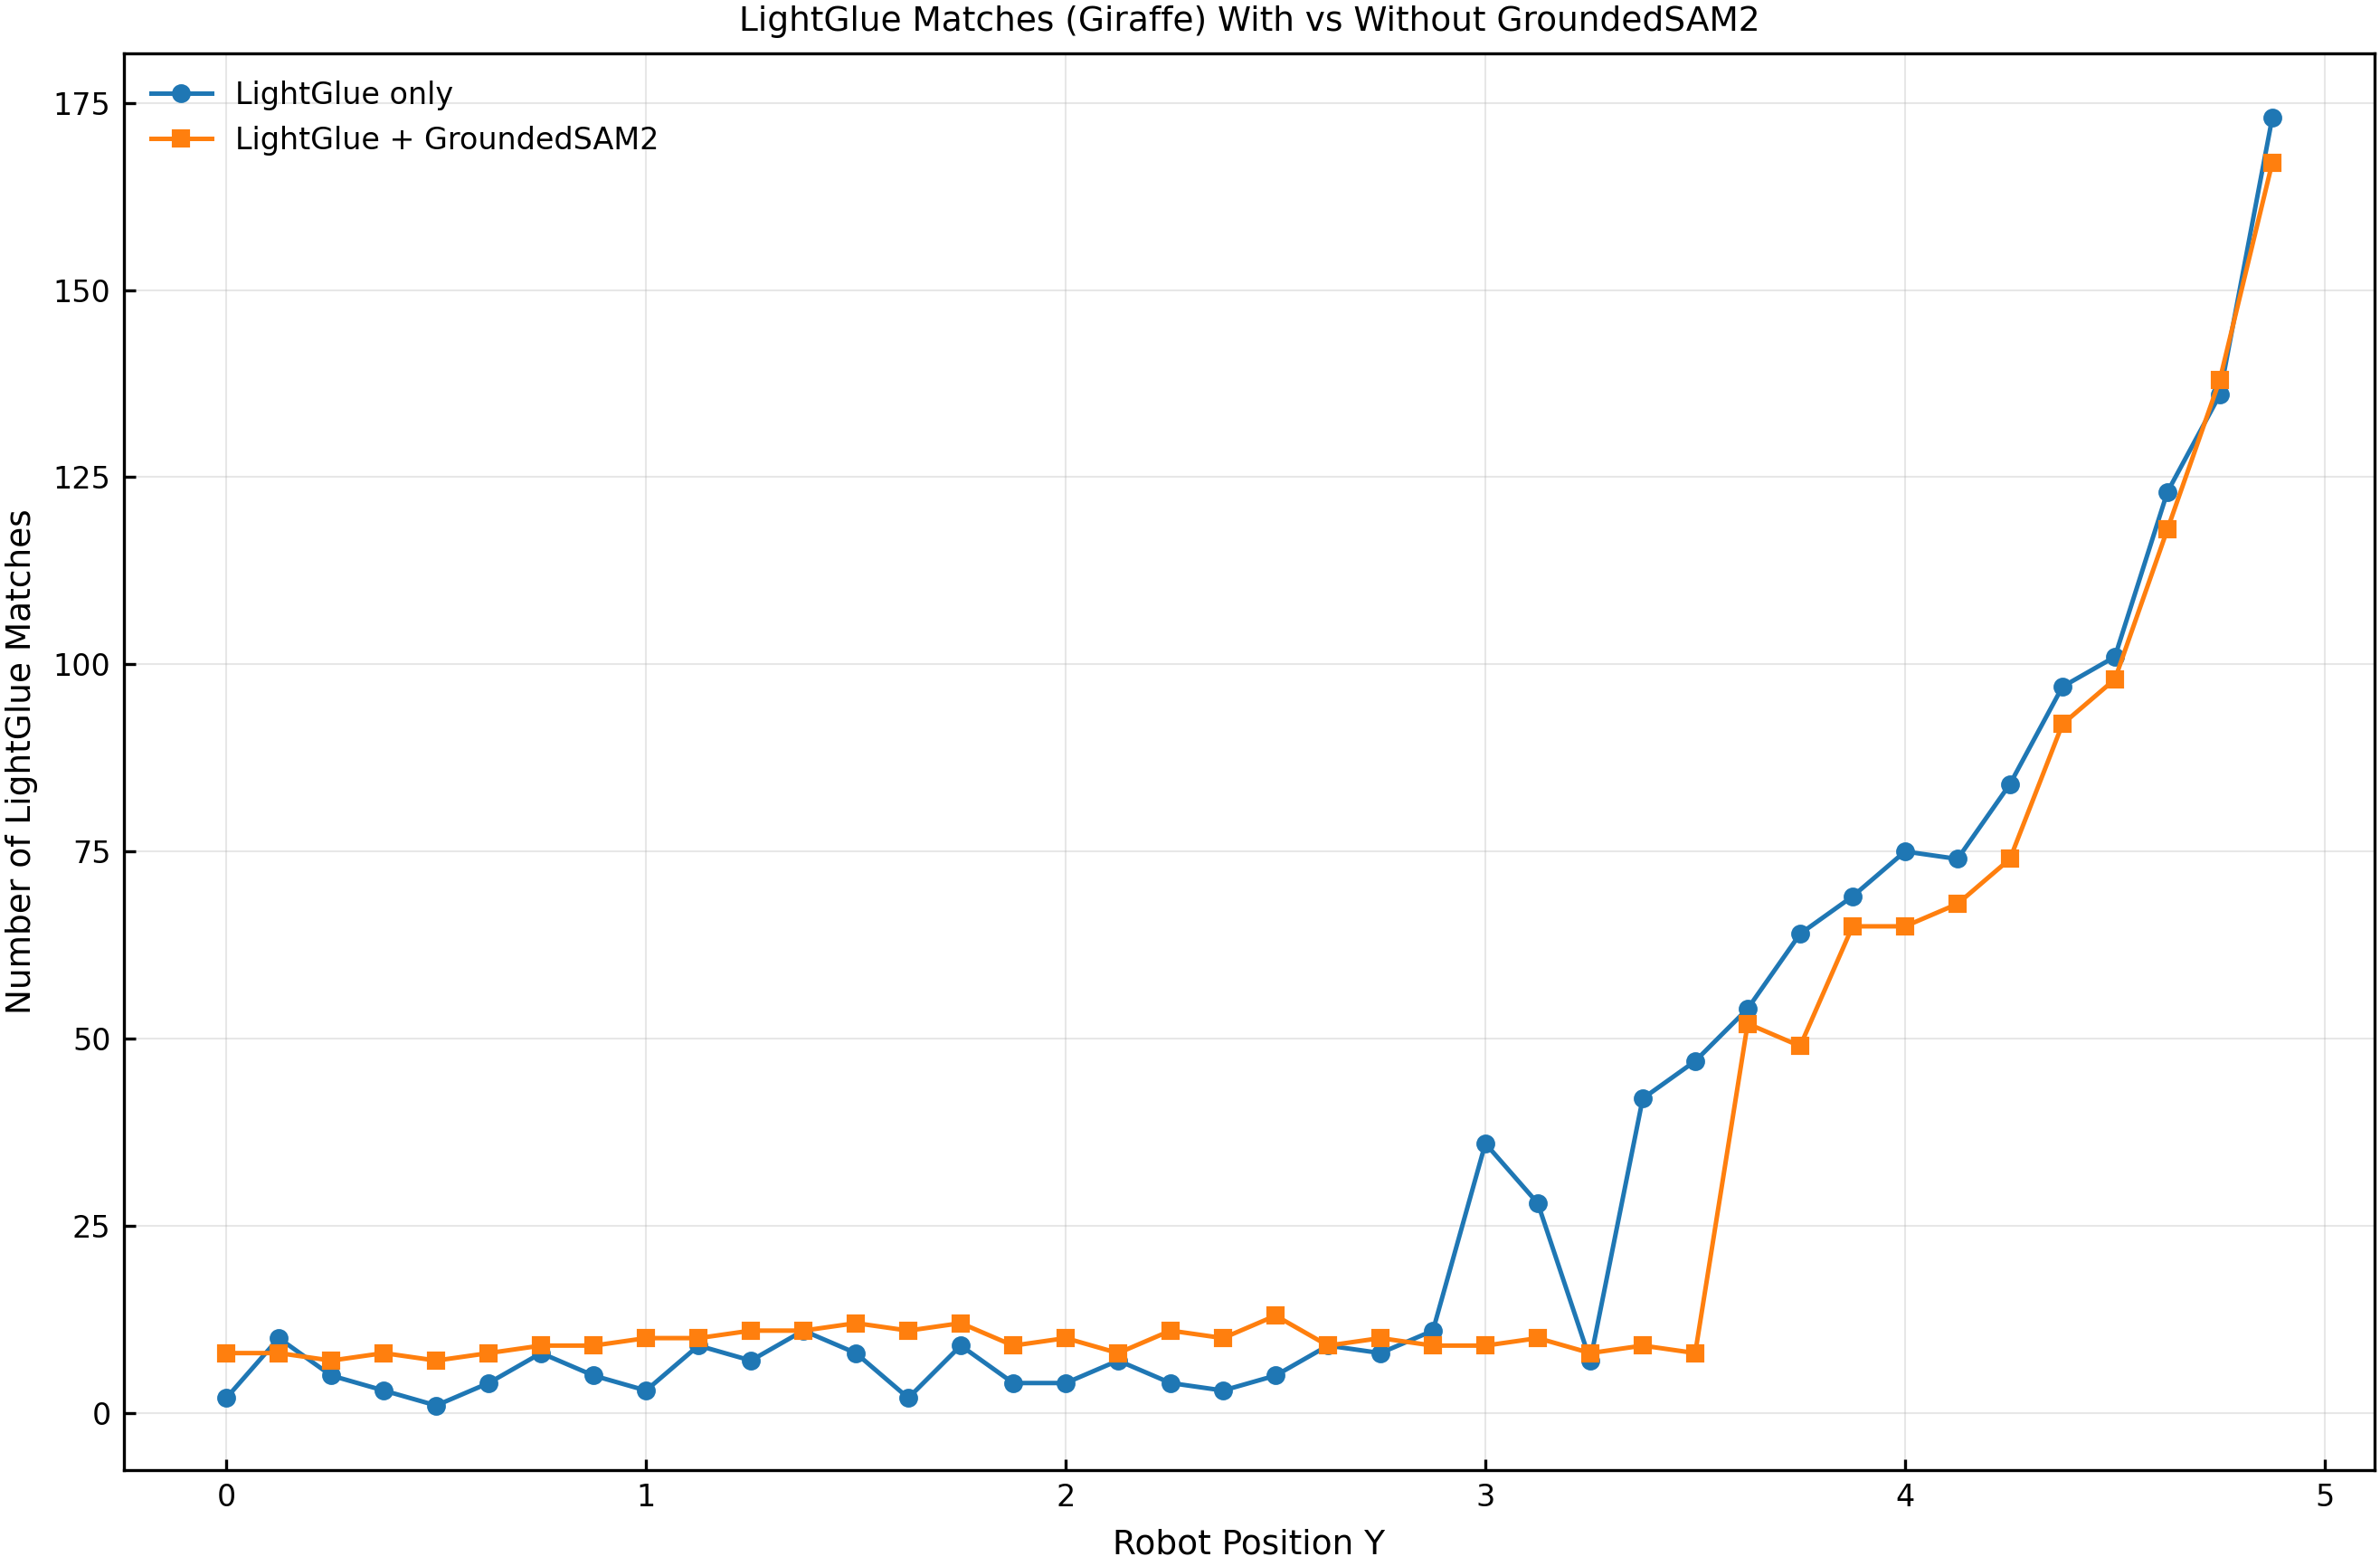

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# Paths to two CSV files
csv_lg = '/home/khw/IBVS-interbotix/results/lightglue_straight_line_giraffe.csv'
csv_gam = '/home/khw/IBVS-interbotix/results/lg_gam_straight_line_giraffe.csv'

# Read both CSVs
df_lg = pd.read_csv(csv_lg)
df_gam = pd.read_csv(csv_gam)

plt.figure(figsize=(9,6))

# Plot num_matches vs robot_pos_y for each CSV
plt.plot(df_lg['robot_pos_y'], df_lg['num_matches'], marker='o', label='LightGlue only')
plt.plot(df_gam['robot_pos_y'], df_gam['num_matches'], marker='s', label='LightGlue + GroundedSAM2')

plt.xlabel('Robot Position Y')
plt.ylabel('Number of LightGlue Matches')
plt.title('LightGlue Matches (Giraffe) With vs Without GroundedSAM2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

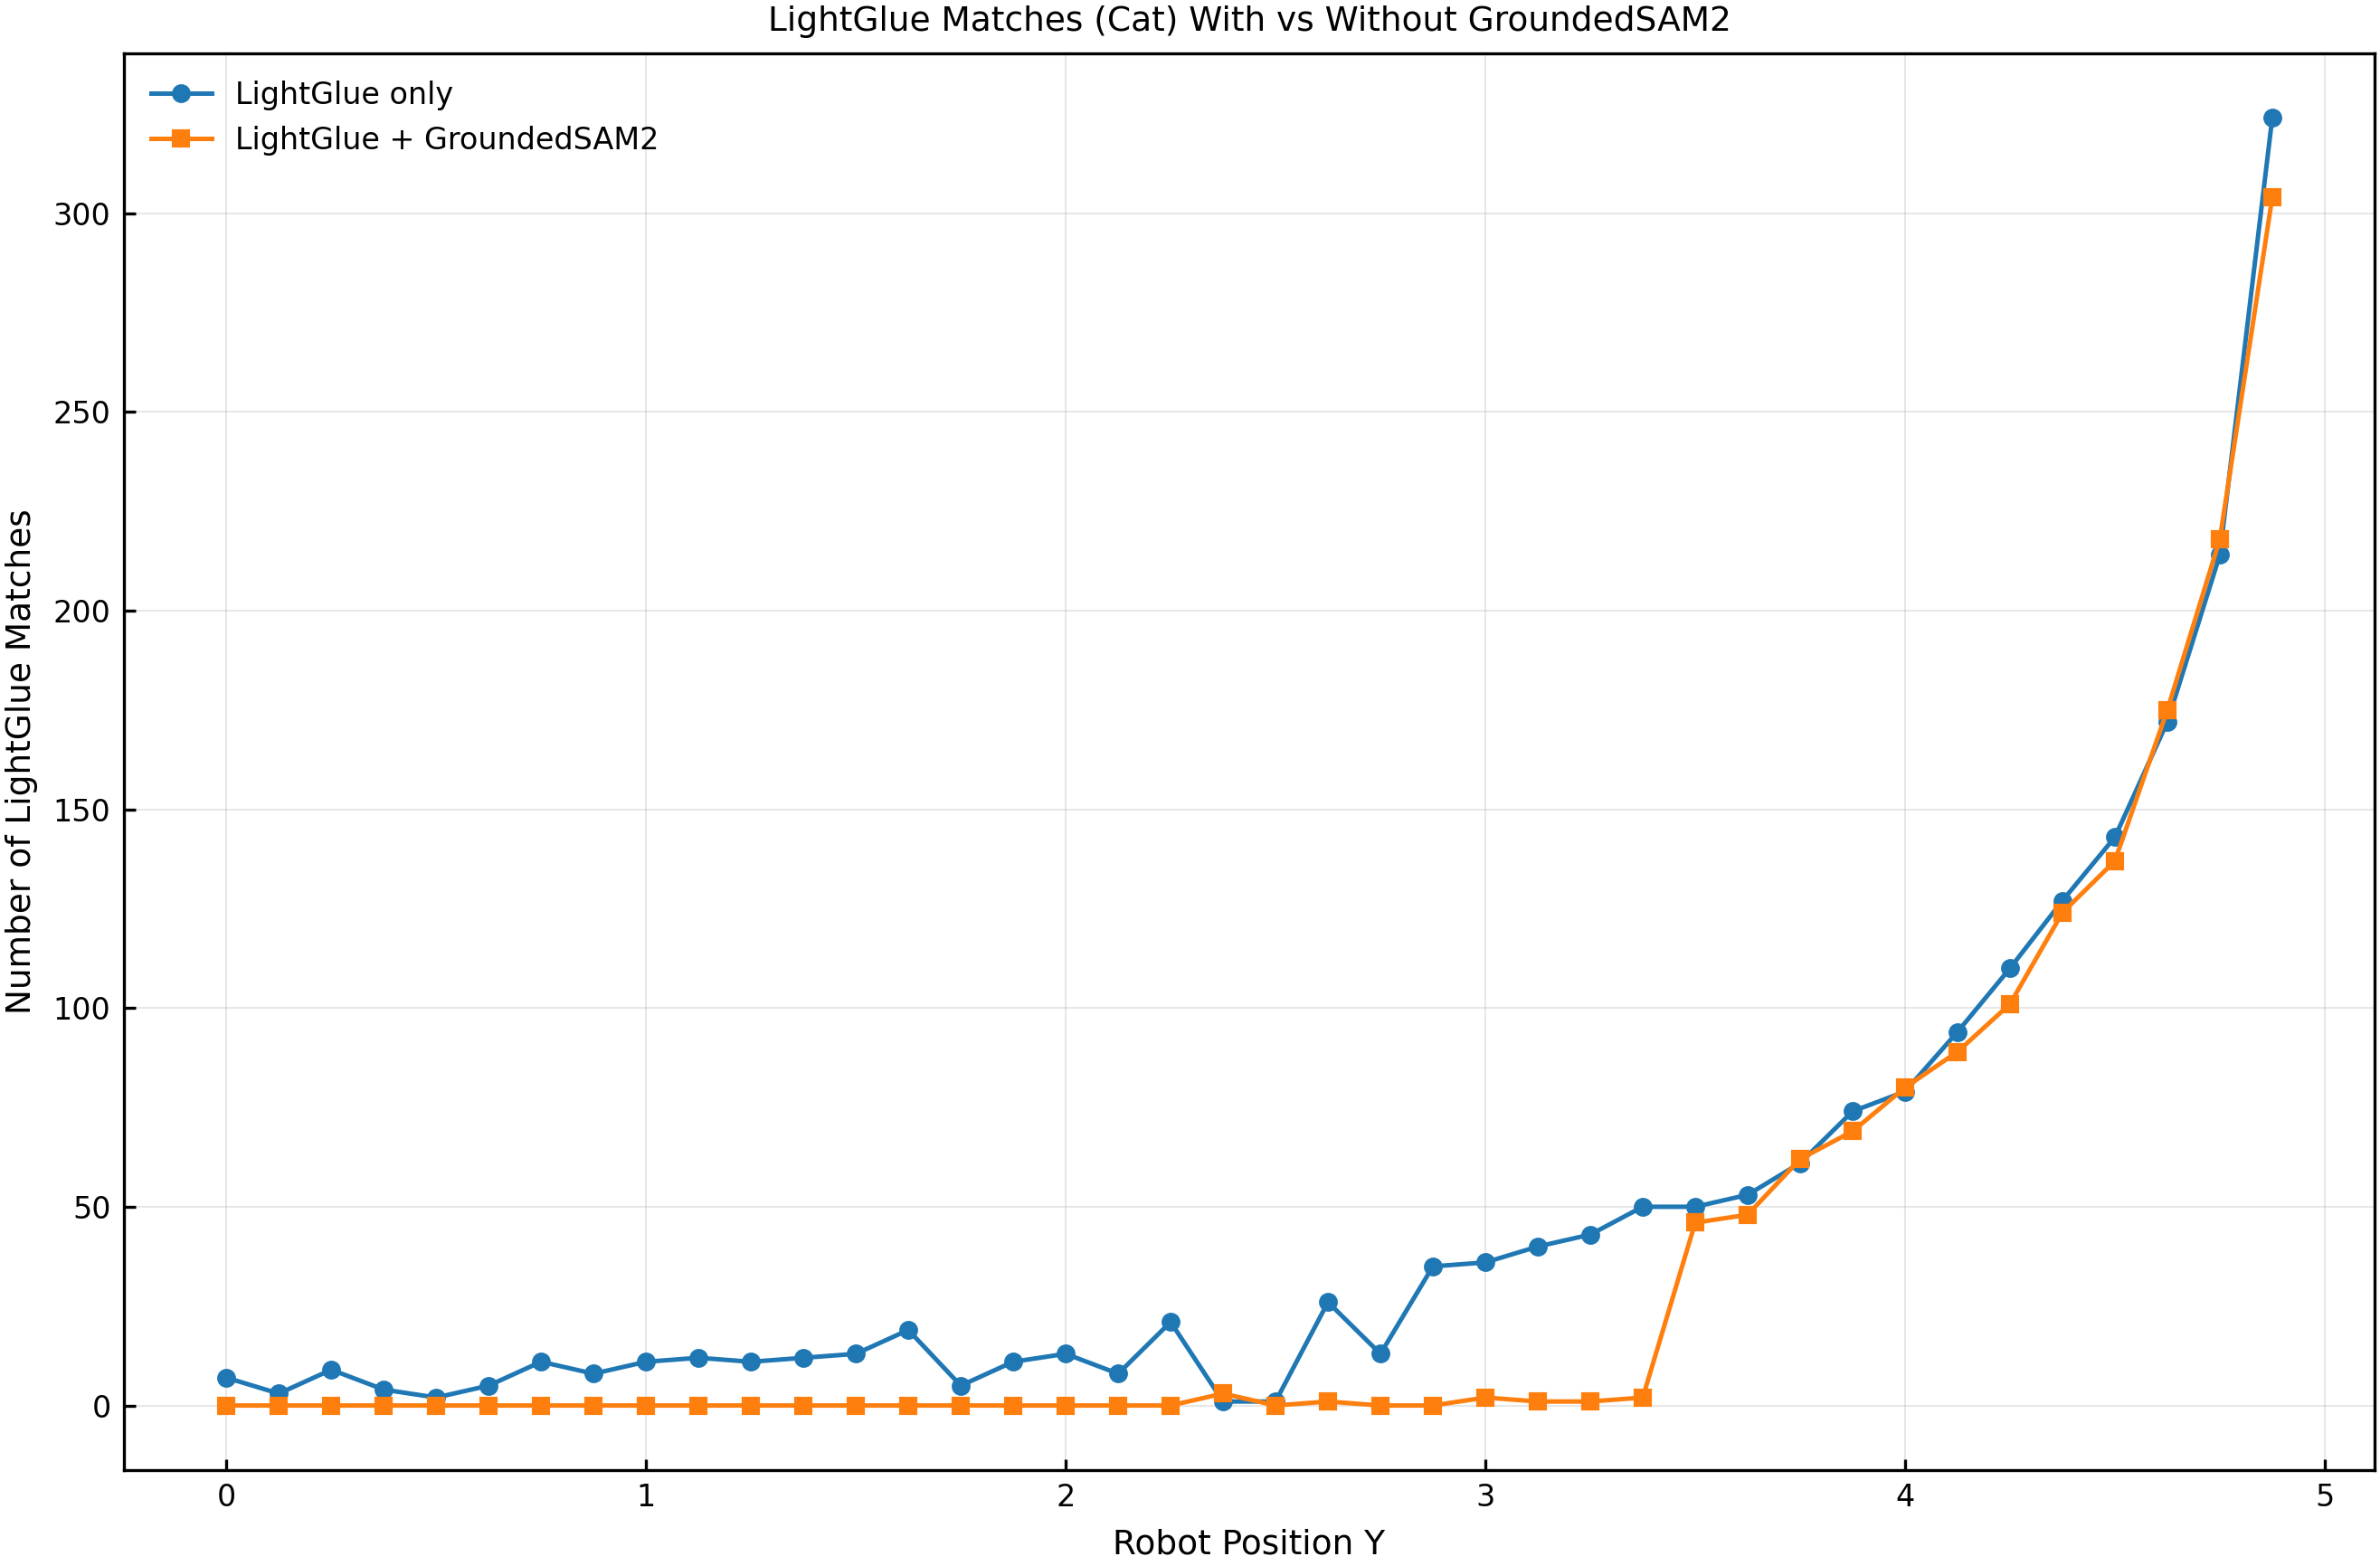

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Paths to two CSV files
csv_lg = '/home/khw/IBVS-interbotix/results/lightglue_straight_line_cat.csv'
csv_gam = '/home/khw/IBVS-interbotix/results/lg_gam_straight_line_cat.csv'

# Read both CSVs
df_lg = pd.read_csv(csv_lg)
df_gam = pd.read_csv(csv_gam)

plt.figure(figsize=(9,6))

# Plot num_matches vs robot_pos_y for each CSV
plt.plot(df_lg['robot_pos_y'], df_lg['num_matches'], marker='o', label='LightGlue only')
plt.plot(df_gam['robot_pos_y'], df_gam['num_matches'], marker='s', label='LightGlue + GroundedSAM2')

plt.xlabel('Robot Position Y')
plt.ylabel('Number of LightGlue Matches')
plt.title('LightGlue Matches (Cat) With vs Without GroundedSAM2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

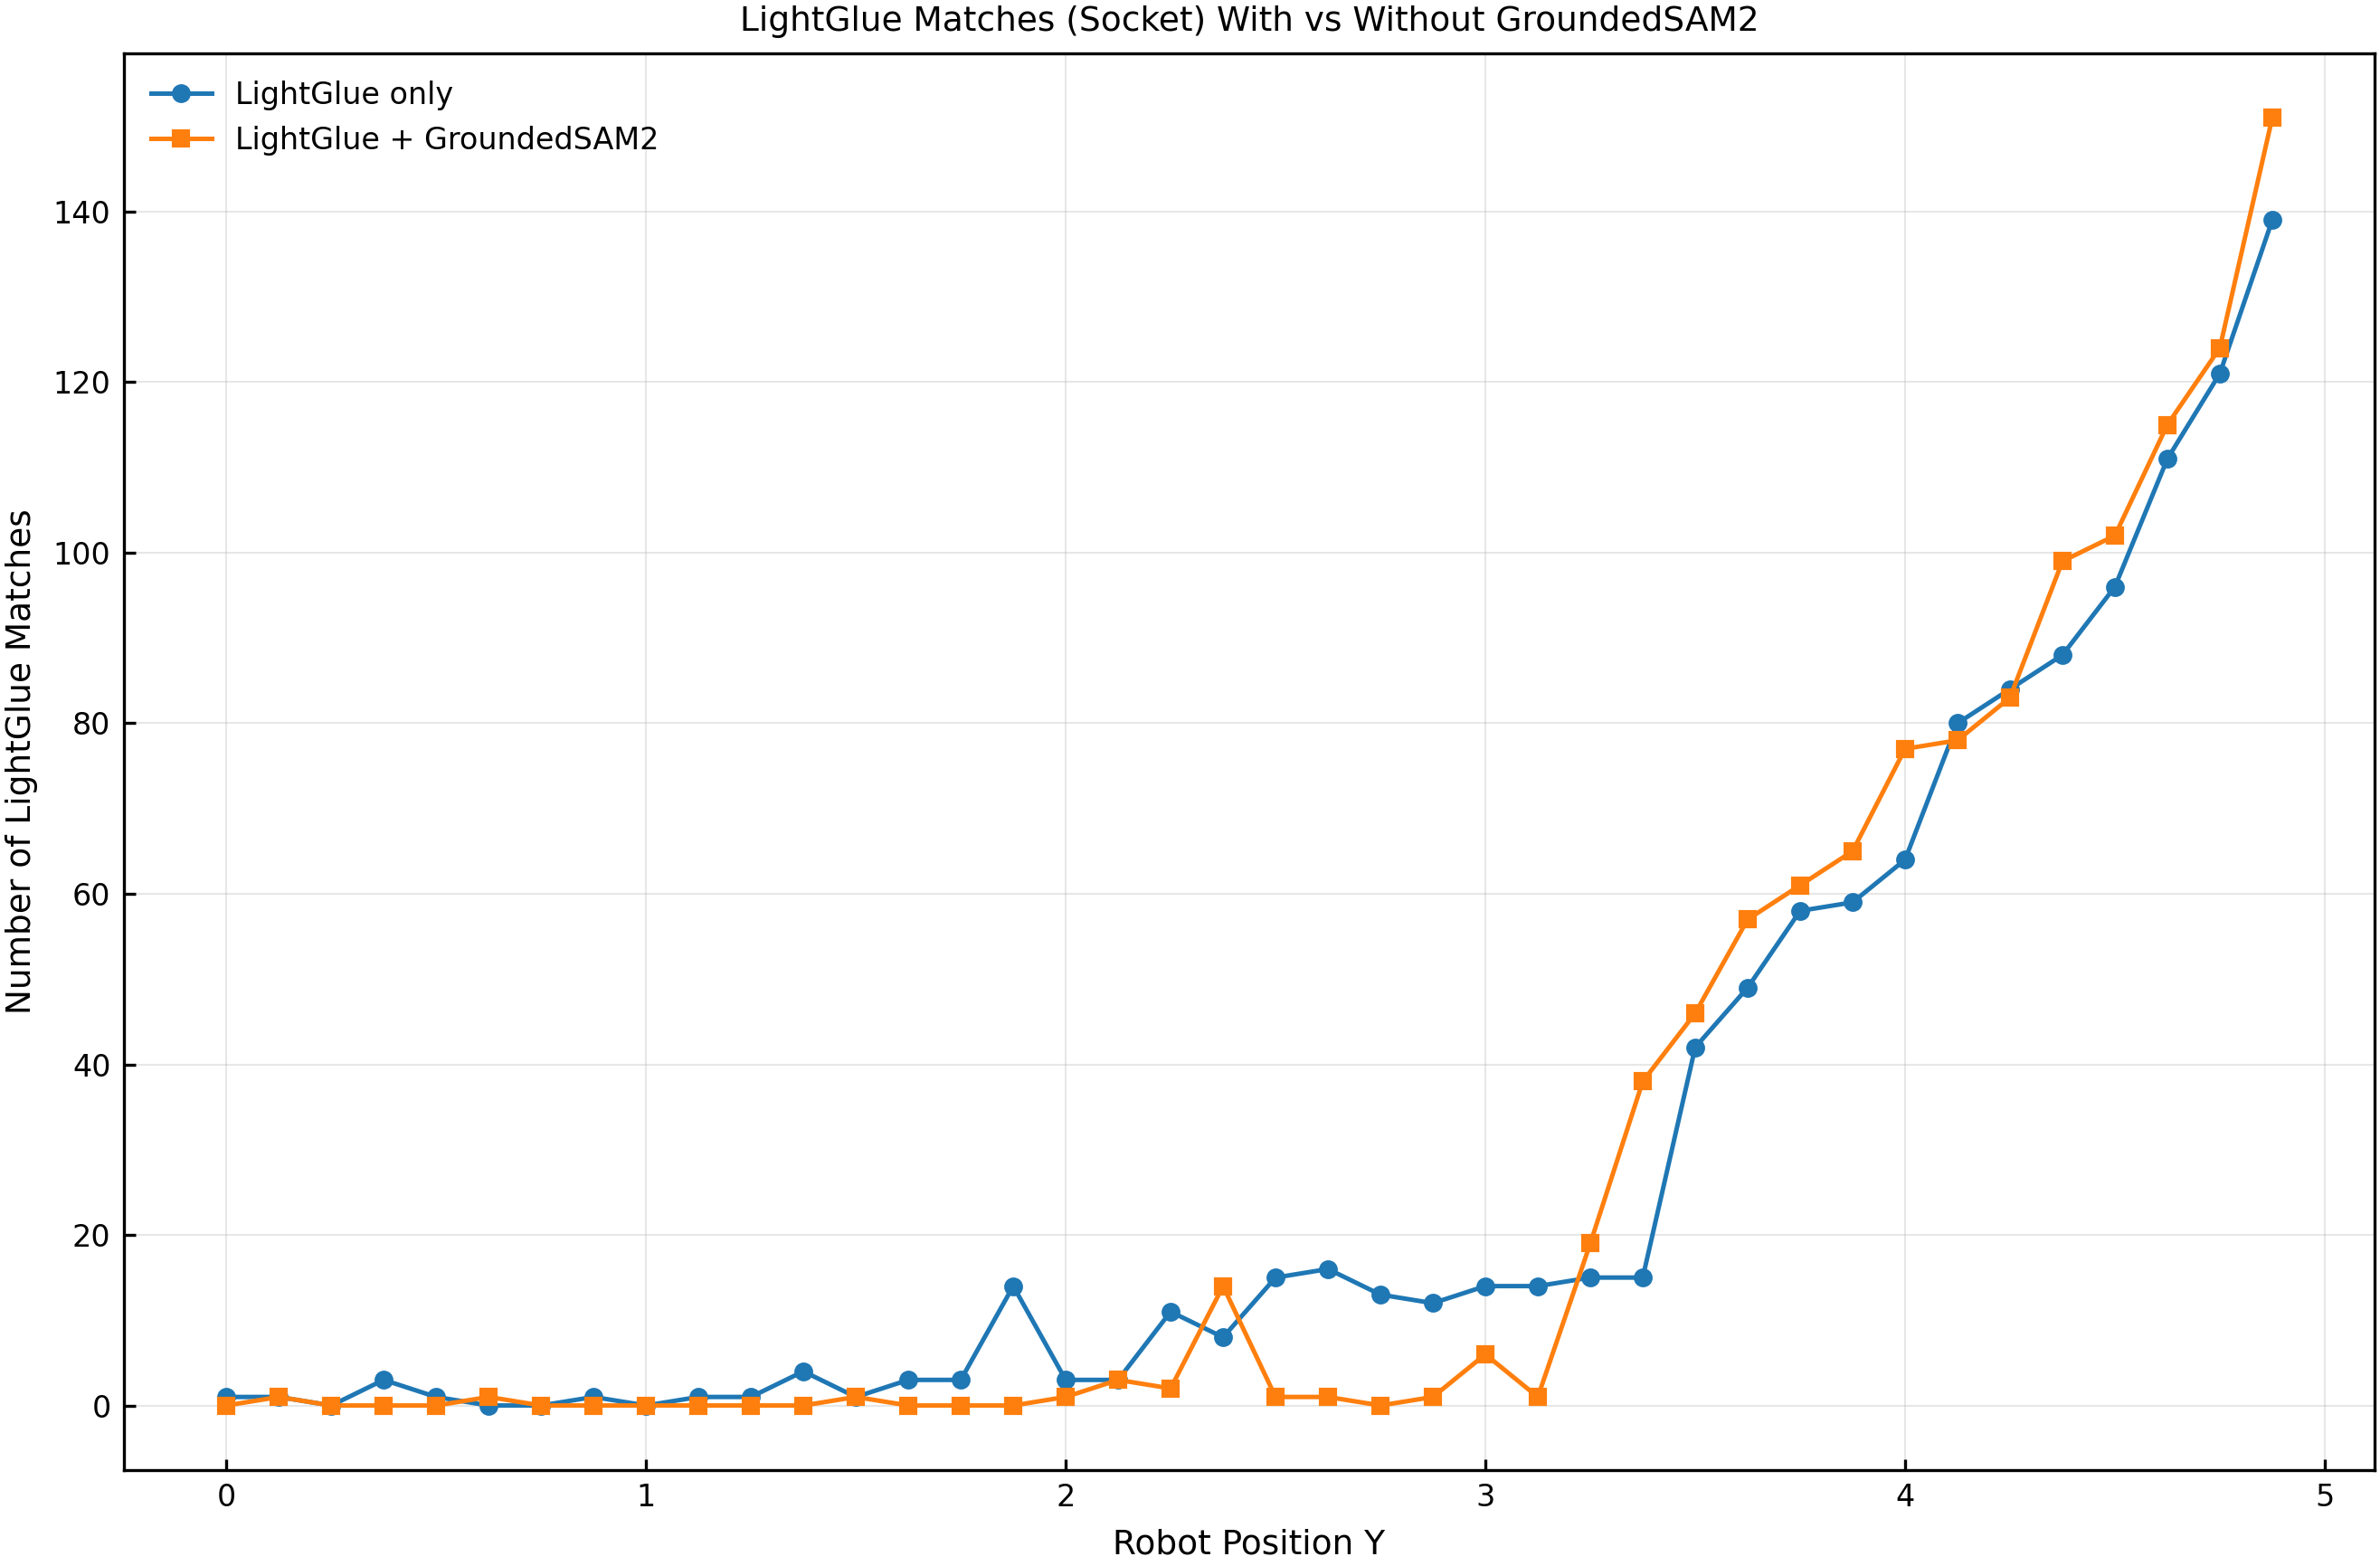

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# Paths to two CSV files
csv_lg = '/home/khw/IBVS-interbotix/results/lightglue_straight_line_socket.csv'
csv_gam = '/home/khw/IBVS-interbotix/results/lg_gam_straight_line_socket.csv'

# Read both CSVs
df_lg = pd.read_csv(csv_lg)
df_gam = pd.read_csv(csv_gam)

plt.figure(figsize=(9,6))

# Plot num_matches vs robot_pos_y for each CSV
plt.plot(df_lg['robot_pos_y'], df_lg['num_matches'], marker='o', label='LightGlue only')
plt.plot(df_gam['robot_pos_y'], df_gam['num_matches'], marker='s', label='LightGlue + GroundedSAM2')

plt.xlabel('Robot Position Y')
plt.ylabel('Number of LightGlue Matches')
plt.title('LightGlue Matches (Socket) With vs Without GroundedSAM2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

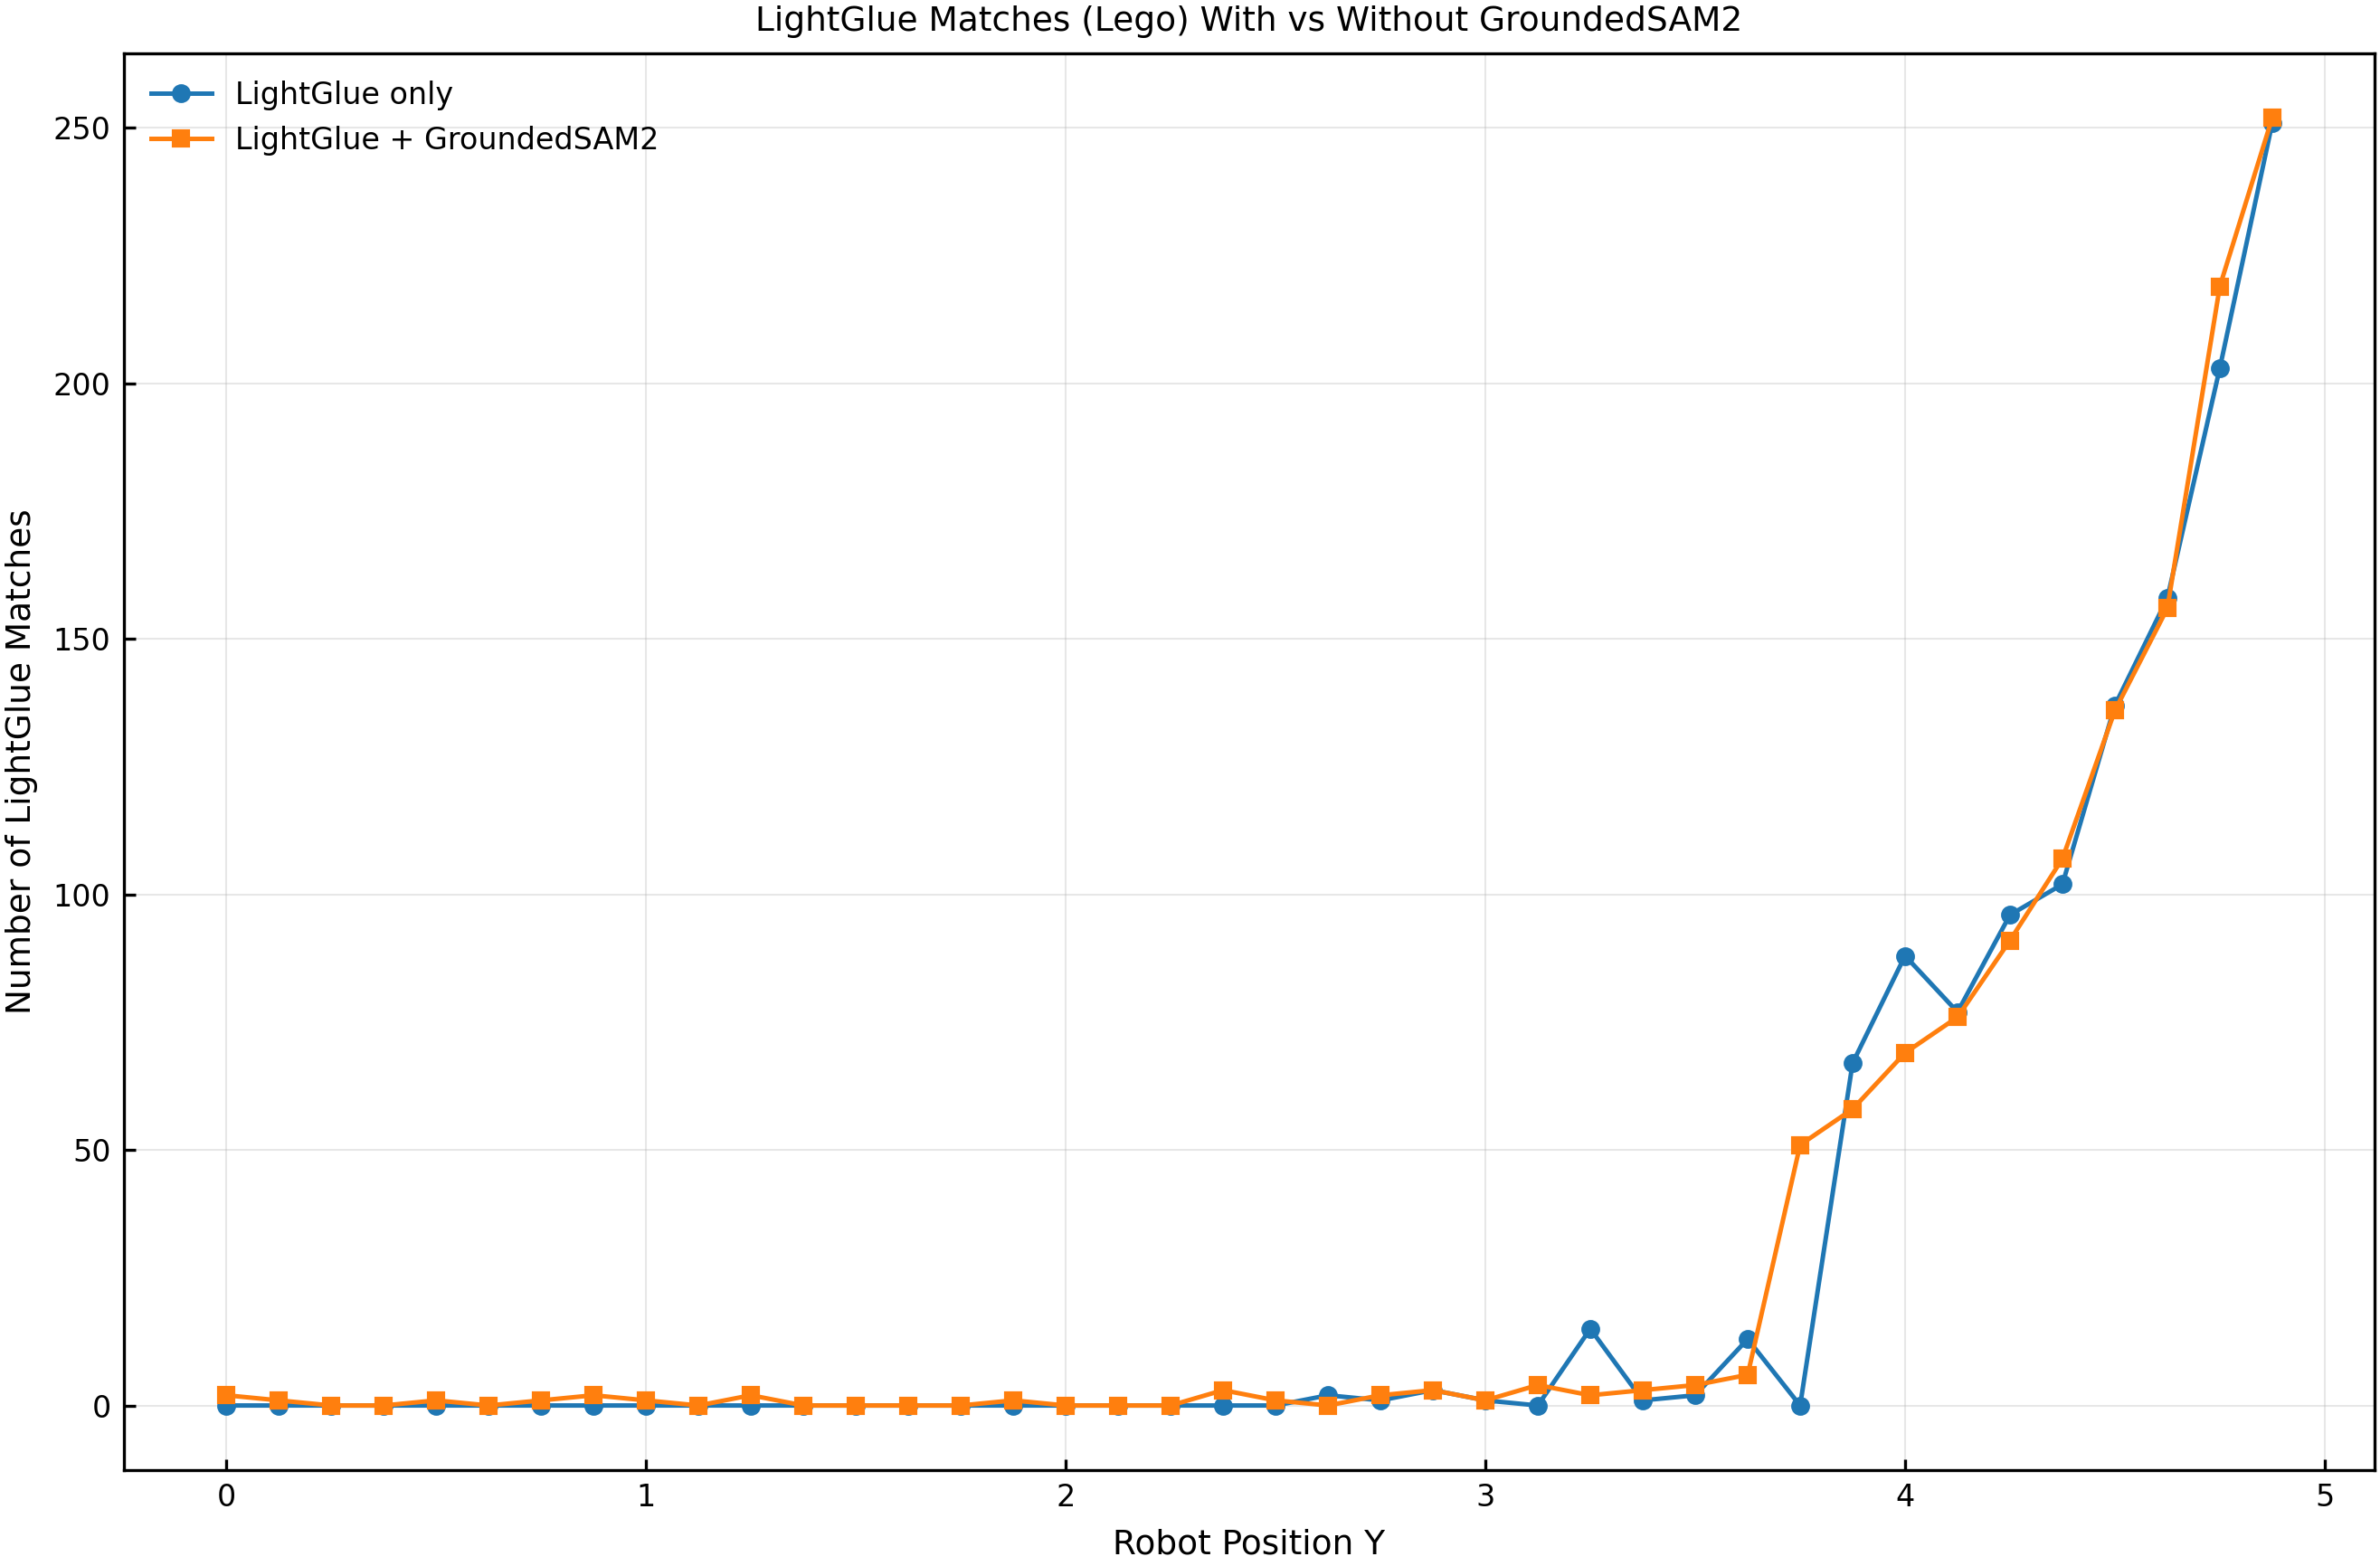

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# Paths to two CSV files
csv_lg = '/home/khw/IBVS-interbotix/results/lightglue_straight_line_lego.csv'
csv_gam = '/home/khw/IBVS-interbotix/results/lg_gam_straight_line_lego.csv'

# Read both CSVs
df_lg = pd.read_csv(csv_lg)
df_gam = pd.read_csv(csv_gam)

plt.figure(figsize=(9,6))

# Plot num_matches vs robot_pos_y for each CSV
plt.plot(df_lg['robot_pos_y'], df_lg['num_matches'], marker='o', label='LightGlue only')
plt.plot(df_gam['robot_pos_y'], df_gam['num_matches'], marker='s', label='LightGlue + GroundedSAM2')

plt.xlabel('Robot Position Y')
plt.ylabel('Number of LightGlue Matches')
plt.title('LightGlue Matches (Lego) With vs Without GroundedSAM2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()